# Baseline 2D Rotated Surface Code — Threshold Sweep

Reproduces **Figure 11 (top-left)** from Duckering et al. 2020, "Virtualized Logical Qubits: A 2.5D Architecture for Error-Corrected Quantum Computing."

**Target threshold:** $p_{\text{th}} \approx 0.009$ (0.9%)

**Stack:** `stim` (circuit + Pauli frame sim) · `pymatching` (MWPM decoder) · `sinter` (parallelized sweep)

---
## Error model (symmetric depolarizing)
| Channel | Location |
|---|---|
| `DEPOLARIZE2(p)` | after every 2-qubit Clifford gate |
| `DEPOLARIZE1(p)` | idle data qubits each round |
| `X_ERROR(p)` | before each measurement |
| `X_ERROR(p)` | after each reset |

In [1]:
import stim
import sinter
import numpy as np
import matplotlib.pyplot as plt
import pymatching


def make_surface_code_circuit(d: int, p: float) -> stim.Circuit:
    """Unrotated surface code with symmetric depolarizing noise."""
    return stim.Circuit.generated(
        "surface_code:unrotated_memory_z",
        rounds=d,
        distance=d,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
        before_round_data_depolarization=p,
    )

## Quick sanity check
Below threshold ($p = 0.005 < p_{\text{th}}$): larger $d$ should give lower logical error rate.

In [2]:
p_test = 0.005
shots = 10_000

print(f"Quick check at p={p_test} (below threshold → larger d should reduce error rate):\n")
for d in [3, 5, 7]:
    circuit = make_surface_code_circuit(d, p_test)
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    sampler = circuit.compile_detector_sampler()
    detection_events, obs_flips = sampler.sample(shots, separate_observables=True)
    predictions = matcher.decode_batch(detection_events)
    rate = np.mean(predictions != obs_flips)
    print(f"  d={d}, p={p_test} → logical error rate = {rate:.5f}")

Quick check at p=0.005 (below threshold → larger d should reduce error rate):

  d=3, p=0.005 → logical error rate = 0.02460
  d=5, p=0.005 → logical error rate = 0.01520
  d=7, p=0.005 → logical error rate = 0.01100


## Full threshold sweep
Sweep $p \in [10^{-3}, 0.05]$ for $d = 3, 5, 7, 9, 11$. Uses `sinter` for parallelized sampling with `pymatching` MWPM decoder.

Convergence: stops at `max_shots` or `max_errors` (whichever comes first). Start with 500k shots; bump to 2M for publication-quality.

In [3]:
distances = [3, 5, 7]
error_rates = np.logspace(-3, np.log10(0.05), 10)

tasks = [
    sinter.Task(
        circuit=make_surface_code_circuit(d, p),
        json_metadata={"d": d, "p": p},
    )
    for d in distances
    for p in error_rates
]

print(f"{len(tasks)} tasks ({len(distances)} distances × {len(error_rates)} error rates)")

results = sinter.collect(
    tasks=tasks,
    num_workers=4,
    max_shots=10_000,
    max_errors=100,
    decoders=["pymatching"],
    print_progress=True,
)

Starting 4 workers...


30 tasks (3 distances × 10 error rates)


30 tasks left:
  workers    decoder eta shots_left errors_left json_metadata              
        1 pymatching   ?      10000         100 d=3,p=0.001                
        1 pymatching   ?      10000         100 d=3,p=0.001544452104946379 
        1 pymatching   ?      10000         100 d=3,p=0.0023853323044733007
        1 pymatching  1m       9999         100 d=3,p=0.0036840314986403863
        0 pymatching ?·∞      10000         100 d=3,p=0.005689810202763908 
        0 pymatching ?·∞      10000         100 d=3,p=0.0087876393444041   
        0 pymatching ?·∞      10000         100 d=3,p=0.013572088082974531 
        0 pymatching ?·∞      10000         100 d=3,p=0.02096144000826768  
        0 pymatching ?·∞      10000         100 d=3,p=0.03237394014347626  
        0 pymatching ?·∞      10000         100 d=3,p=0.049999999999999996 
        0 pymatching ?·∞      10000         100 d=5,p=0.001                
        0 pymatching ?·∞      10000         100 d=5,p=0.00154445210494637

## Threshold plot
Expect crossing at $p_{\text{th}} \approx 0.009$.

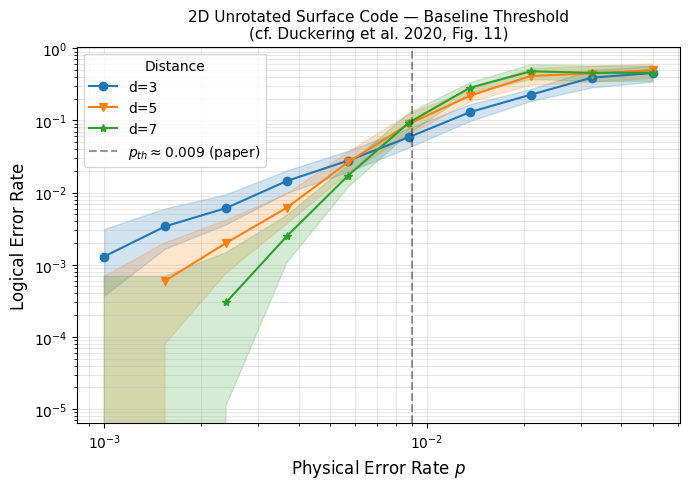

In [4]:
import os
os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))

sinter.plot_error_rate(
    ax=ax,
    stats=results,
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: f"d={stat.json_metadata['d']}",
    failure_units_per_shot_func=lambda stat: 1,
)

ax.axvline(x=0.009, color="k", linestyle="--", alpha=0.4, label="$p_{th} \\approx 0.009$ (paper)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical Error Rate $p$", fontsize=12)
ax.set_ylabel("Logical Error Rate", fontsize=12)
ax.set_title("2D Unrotated Surface Code — Baseline Threshold\n(cf. Duckering et al. 2020, Fig. 11)", fontsize=11)
ax.legend(title="Distance")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("results/threshold_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

---
# T1/T2 Decay Noise Model (Asymmetric Pauli Channels)

## Why move beyond symmetric depolarizing?

The baseline model above uses a single parameter `p` for all noise — every gate, idle period, 
and measurement fails with the same probability, and X/Y/Z errors are equally likely. 
This is unphysical:

1. **T1 (energy relaxation)** causes the qubit to decay from |1⟩ → |0⟩. This produces 
   **X and Y errors** (bit flips). Longer T1 = slower decay = fewer errors.

2. **T2 (dephasing)** causes loss of phase coherence. This produces **Z errors** (phase flips).
   T2 is bounded: T2 ≤ 2·T1 (T1 processes also cause dephasing). When T2 = 2·T1, 
   there is no "pure dephasing" — all dephasing comes from T1. When T2 < 2·T1, there is 
   extra pure dephasing on top.

3. **Different operations take different amounts of time**, so they accumulate different 
   amounts of T1/T2 error. A 50 ns single-qubit gate has ~4x less decoherence than a 
   200 ns two-qubit gate, and ~30x less than a ~1.6 µs idle period.

## Pauli twirl approximation

Real T1/T2 decay is not a Pauli channel — amplitude damping is non-unitary. But we can 
**Pauli twirl** it: average over random Pauli rotations before and after, which projects 
the channel onto the nearest Pauli channel. This is standard practice in QEC simulations 
and gives:

$$p_x = p_y = \frac{1}{4}\left(1 - e^{-t/T_1}\right)$$

$$p_z = \frac{1}{2}\left(1 - e^{-t/T_2}\right) - \frac{1}{4}\left(1 - e^{-t/T_1}\right)$$

where $t$ is the duration of the operation/idle. Note:
- When $T_2 = 2 T_1$: $p_z = \frac{1}{4}(1-e^{-t/T_1}) - \frac{1}{2}(1-e^{-t/2T_1}+...)$ — Z errors come entirely from T1
- When $T_2 \ll T_1$: $p_z \gg p_x$ — dephasing dominates, mostly Z errors
- When $T_2 = T_1$: mixed regime

## What we replace

| Stim's symmetric channel | Our asymmetric replacement |
|---|---|
| `DEPOLARIZE1(p)` on idle qubits | `PAULI_CHANNEL_1(px, py, pz)` with T1/T2-derived rates for idle duration |
| `DEPOLARIZE2(p)` after 2Q gates | `PAULI_CHANNEL_2(15 probs)` — tensor product of single-qubit T1/T2 channels for gate duration |
| `X_ERROR(p)` before measurement | `X_ERROR(p)` with p from T1 during measurement time (unchanged — already asymmetric) |
| `X_ERROR(p)` after reset | `X_ERROR(p)` with p from T1 during reset time (unchanged) |

In [5]:
def t1t2_pauli_probs(t: float, T1: float, T2: float):
    """
    Pauli-twirled amplitude damping + dephasing channel.
    
    Given an idle/gate duration t and coherence times T1, T2, returns
    the probability of each single-qubit Pauli error (px, py, pz).
    
    Derivation:
      - Amplitude damping (T1): qubit relaxes |1⟩→|0⟩ with prob 1-exp(-t/T1).
        Under Pauli twirl, this becomes X and Y errors each with prob (1-exp(-t/T1))/4.
      - Dephasing (T2): phase coherence decays as exp(-t/T2).
        Under Pauli twirl, this adds Z errors. The total pz includes contributions
        from both T1 (which also dephases) and pure dephasing (T_phi).
        Recall: 1/T2 = 1/(2*T1) + 1/T_phi
    
    Returns: (px, py, pz) where px=py (T1 is symmetric in X/Y under twirl)
    """
    p_relax = 1 - np.exp(-t / T1)     # probability of T1 relaxation event
    p_dephase = 1 - np.exp(-t / T2)   # probability of T2 dephasing event
    
    px = p_relax / 4        # X error from amplitude damping
    py = p_relax / 4        # Y error from amplitude damping
    pz = p_dephase / 2 - p_relax / 4  # Z error: dephasing minus the T1 contribution
    pz = max(pz, 0.0)       # guard against numerical issues when T2 ≈ 2*T1
    
    return px, py, pz


def two_qubit_pauli_channel(px: float, py: float, pz: float):
    """
    Tensor product of two independent single-qubit Pauli channels.
    
    If each qubit independently undergoes Pauli errors with probs (px, py, pz),
    the 2-qubit channel has 15 non-identity terms. Stim's PAULI_CHANNEL_2 
    expects them in order: IX, IY, IZ, XI, XX, XY, XZ, YI, YX, YY, YZ, ZI, ZX, ZY, ZZ.
    
    This assumes the two qubits have the SAME T1/T2 (both are transmons).
    If they differ (e.g., transmon-cavity), pass different (px, py, pz) for each.
    """
    pI = 1 - px - py - pz  # probability of no error on one qubit
    
    # Each entry is P(error_on_qubit_A) * P(error_on_qubit_B)
    probs = [
        pI * px,   # IX
        pI * py,   # IY
        pI * pz,   # IZ
        px * pI,   # XI
        px * px,   # XX
        px * py,   # XY
        px * pz,   # XZ
        py * pI,   # YI
        py * px,   # YX
        py * py,   # YY
        py * pz,   # YZ
        pz * pI,   # ZI
        pz * px,   # ZX
        pz * py,   # ZY
        pz * pz,   # ZZ
    ]
    return probs


def replace_noise_with_t1t2(
    circuit: stim.Circuit,
    T1: float,
    T2: float,
    t_2q: float,
    t_idle: float,
) -> stim.Circuit:
    """
    Post-process a Stim circuit: replace symmetric DEPOLARIZE channels 
    with asymmetric PAULI_CHANNEL derived from T1/T2.
    
    How it works:
      1. Walk through every instruction in the circuit
      2. DEPOLARIZE1 → PAULI_CHANNEL_1(px, py, pz) using idle-time T1/T2 decay
      3. DEPOLARIZE2 → PAULI_CHANNEL_2(15 probs) using gate-time T1/T2 decay
      4. X_ERROR, M, R, DETECTOR, etc. → keep as-is
      5. REPEAT blocks → recurse into the block body
    
    Note: Stim's generator puts DEPOLARIZE1 for idle errors and DEPOLARIZE2 
    for gate errors. We replace both with the appropriate asymmetric channel.
    """
    # Compute asymmetric Pauli probs for each context
    px_idle, py_idle, pz_idle = t1t2_pauli_probs(t_idle, T1, T2)
    px_gate, py_gate, pz_gate = t1t2_pauli_probs(t_2q, T1, T2)
    pauli2_probs = two_qubit_pauli_channel(px_gate, py_gate, pz_gate)
    
    new_circuit = stim.Circuit()
    
    for instruction in circuit:
        if isinstance(instruction, stim.CircuitRepeatBlock):
            # Recurse into repeat blocks (the syndrome extraction rounds)
            new_body = replace_noise_with_t1t2(instruction.body_copy(), T1, T2, t_2q, t_idle)
            new_circuit.append(stim.CircuitRepeatBlock(instruction.repeat_count, new_body))
        elif instruction.name == 'DEPOLARIZE1':
            # Replace symmetric depol with asymmetric Pauli channel
            targets = instruction.targets_copy()
            new_circuit.append('PAULI_CHANNEL_1', targets, [px_idle, py_idle, pz_idle])
        elif instruction.name == 'DEPOLARIZE2':
            # Replace 2Q symmetric depol with tensor-product Pauli channel
            targets = instruction.targets_copy()
            new_circuit.append('PAULI_CHANNEL_2', targets, pauli2_probs)
        else:
            # Keep everything else: X_ERROR, R, M, H, CX, DETECTOR, OBSERVABLE_INCLUDE, TICK, etc.
            new_circuit.append(instruction)
    
    return new_circuit


def make_t1t2_surface_code(
    d: int,
    T1: float = 100e-6,       # 100 µs
    T2: float = 100e-6,       # 100 µs (can be up to 2*T1)
    t_1q: float = 50e-9,      # single-qubit gate time
    t_2q: float = 200e-9,     # two-qubit gate time
    t_meas: float = 600e-9,   # measurement time
    t_reset: float = 200e-9,  # reset time
    verbose: bool = True,
) -> stim.Circuit:
    """
    Build unrotated surface code with T1/T2 asymmetric noise model.
    
    Strategy:
      1. Compute error rates from T1, T2, and operation durations
      2. Generate circuit with Stim's built-in generator (uses symmetric DEPOLARIZE)
      3. Post-process: replace DEPOLARIZE1/2 with PAULI_CHANNEL_1/2
         using the asymmetric T1/T2-derived probabilities
      4. Keep X_ERROR for measurement/reset (already asymmetric — only bit flips)
    
    Timing model for one syndrome round:
      - 4 CNOT layers (each t_2q = 200 ns)  →  800 ns of gate time
      - 1 measurement (t_meas = 600 ns)
      - 1 reset (t_reset = 200 ns)
      - Total round time: ~1.6 µs
      - Data qubits idle for the full round (only active during their CNOT)
    """
    assert T2 <= 2 * T1 + 1e-15, f"Unphysical: T2={T2} > 2*T1={2*T1}"
    
    # --- Compute error rates from coherence times ---
    
    # Idle: data qubits sit idle for a full syndrome round
    t_idle = 4 * t_2q + t_meas + t_reset
    px_idle, py_idle, pz_idle = t1t2_pauli_probs(t_idle, T1, T2)
    
    # 2Q gate: decoherence during the CNOT gate itself
    px_gate, py_gate, pz_gate = t1t2_pauli_probs(t_2q, T1, T2)
    
    # Measurement: T1 decay during readout can flip |1⟩→|0⟩
    # This is a pure bit-flip error — only T1 matters (not T2)
    p_meas = (1 - np.exp(-t_meas / T1)) / 2
    
    # Reset: T1 decay after reset can excite qubit
    p_reset = (1 - np.exp(-t_reset / T1)) / 2
    
    # We need some p value for the generator (will be replaced anyway)
    # Use total error probability as placeholder
    p_gate_placeholder = px_gate + py_gate + pz_gate
    p_idle_placeholder = px_idle + py_idle + pz_idle
    
    if verbose:
        print(f"T1 = {T1*1e6:.1f} µs,  T2 = {T2*1e6:.1f} µs,  T2/T1 = {T2/T1:.2f}")
        print(f"Round time = {t_idle*1e6:.1f} µs")
        print(f"  Idle errors (per round):  px={px_idle:.2e}, py={py_idle:.2e}, pz={pz_idle:.2e}  (total={p_idle_placeholder:.2e})")
        print(f"  2Q gate errors:           px={px_gate:.2e}, py={py_gate:.2e}, pz={pz_gate:.2e}  (total={p_gate_placeholder:.2e})")
        print(f"  Measurement flip:         p={p_meas:.2e}")
        print(f"  Reset flip:               p={p_reset:.2e}")
        if T2 < 2 * T1:
            print(f"  → Z-biased regime: pz/px = {pz_idle/max(px_idle,1e-30):.1f}x for idle")
        else:
            print(f"  → No pure dephasing (T2 = 2*T1)")
    
    # Step 1: Generate circuit with placeholder symmetric noise
    circuit = stim.Circuit.generated(
        "surface_code:unrotated_memory_z",
        rounds=d,
        distance=d,
        after_clifford_depolarization=p_gate_placeholder,
        after_reset_flip_probability=p_reset,
        before_measure_flip_probability=p_meas,
        before_round_data_depolarization=p_idle_placeholder,
    )
    
    # Step 2: Replace DEPOLARIZE1/2 with asymmetric PAULI_CHANNEL_1/2
    circuit = replace_noise_with_t1t2(circuit, T1, T2, t_2q, t_idle)
    
    return circuit


# --- Demo: compare symmetric vs asymmetric error budgets ---
print("=" * 60)
print("Example: T1 = 100 µs, T2 = 100 µs (T2/T1 = 1.0)")
print("=" * 60)
circuit = make_t1t2_surface_code(d=3, T1=100e-6, T2=100e-6)
print(f"\nCircuit: {circuit.num_qubits} qubits, {circuit.num_ticks} ticks")

print("\n" + "=" * 60)
print("Example: T1 = 100 µs, T2 = 200 µs (T2 = 2*T1, no pure dephasing)")
print("=" * 60)
circuit2 = make_t1t2_surface_code(d=3, T1=100e-6, T2=200e-6)

print("\n" + "=" * 60)
print("Example: T1 = 100 µs, T2 = 30 µs (strong dephasing)")
print("=" * 60)
circuit3 = make_t1t2_surface_code(d=3, T1=100e-6, T2=30e-6)

Example: T1 = 100 µs, T2 = 100 µs (T2/T1 = 1.0)
T1 = 100.0 µs,  T2 = 100.0 µs,  T2/T1 = 1.00
Round time = 1.6 µs
  Idle errors (per round):  px=3.97e-03, py=3.97e-03, pz=3.97e-03  (total=1.19e-02)
  2Q gate errors:           px=5.00e-04, py=5.00e-04, pz=5.00e-04  (total=1.50e-03)
  Measurement flip:         p=2.99e-03
  Reset flip:               p=9.99e-04
  → Z-biased regime: pz/px = 1.0x for idle

Circuit: 25 qubits, 21 ticks

Example: T1 = 100 µs, T2 = 200 µs (T2 = 2*T1, no pure dephasing)
T1 = 100.0 µs,  T2 = 200.0 µs,  T2/T1 = 2.00
Round time = 1.6 µs
  Idle errors (per round):  px=3.97e-03, py=3.97e-03, pz=1.59e-05  (total=7.95e-03)
  2Q gate errors:           px=5.00e-04, py=5.00e-04, pz=2.50e-07  (total=9.99e-04)
  Measurement flip:         p=2.99e-03
  Reset flip:               p=9.99e-04
  → No pure dephasing (T2 = 2*T1)

Example: T1 = 100 µs, T2 = 30 µs (strong dephasing)
T1 = 100.0 µs,  T2 = 30.0 µs,  T2/T1 = 0.30
Round time = 1.6 µs
  Idle errors (per round):  px=3.97e-03,

## T1/T2 sweep: logical error rate vs coherence time

Now we can ask: **how good do T1/T2 need to be for error correction to help?**

Sweep T1 from 10 µs to 500 µs. For each T1, build the asymmetric noise circuit and 
measure the logical error rate. If larger distance d gives lower error rate, we are 
below threshold — error correction is working.

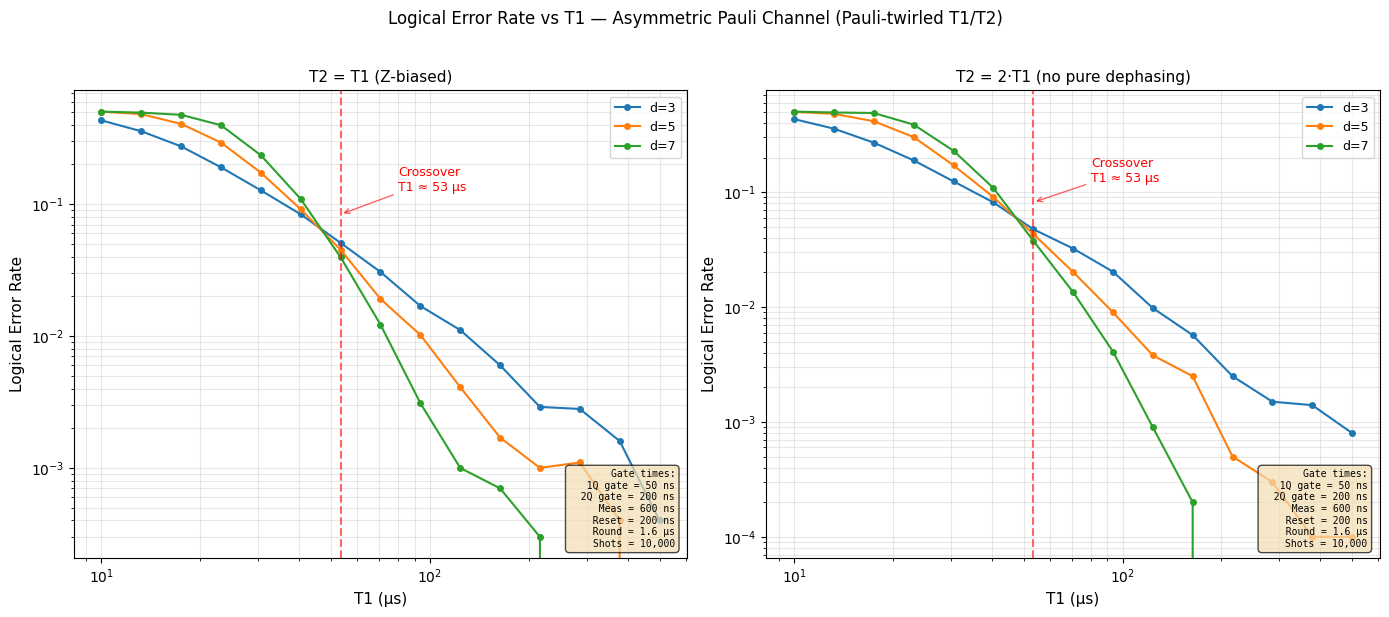

In [6]:
# Gate time assumptions (printed on plot)
t_1q = 50e-9    # 50 ns
t_2q = 200e-9   # 200 ns
t_meas = 600e-9 # 600 ns
t_reset = 200e-9 # 200 ns
t_round = 4 * t_2q + t_meas + t_reset  # ~1.6 µs

distances = [3, 5, 7]
T1_values = np.logspace(np.log10(10e-6), np.log10(500e-6), 15)
shots = 10_000

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

param_text = (
    f"Gate times:\n"
    f"  1Q gate = {t_1q*1e9:.0f} ns\n"
    f"  2Q gate = {t_2q*1e9:.0f} ns\n"
    f"  Meas = {t_meas*1e9:.0f} ns\n"
    f"  Reset = {t_reset*1e9:.0f} ns\n"
    f"  Round = {t_round*1e6:.1f} µs\n"
    f"Shots = {shots:,}"
)

for panel_idx, (T2_label, T2_func) in enumerate([
    ("T2 = T1 (Z-biased)", lambda T1: T1),
    ("T2 = 2·T1 (no pure dephasing)", lambda T1: 2*T1),
]):
    ax = axes[panel_idx]
    all_rates = {}
    
    for d in distances:
        rates = []
        for T1 in T1_values:
            circuit = make_t1t2_surface_code(
                d, T1=T1, T2=T2_func(T1),
                t_1q=t_1q, t_2q=t_2q, t_meas=t_meas, t_reset=t_reset,
                verbose=False,
            )
            dem = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
            matcher = pymatching.Matching.from_detector_error_model(dem)
            sampler = circuit.compile_detector_sampler()
            det_events, obs_flips = sampler.sample(shots, separate_observables=True)
            predictions = matcher.decode_batch(det_events)
            rate = np.mean(predictions != obs_flips)
            rates.append(rate)
        all_rates[d] = np.array(rates)
        ax.plot(T1_values * 1e6, rates, 'o-', label=f'd={d}', markersize=4)
    
    # Find crossover: where d=3 and d=7 curves cross
    # (crossover = threshold in T1 space: below this T1, larger d hurts)
    r3 = all_rates[3]
    r7 = all_rates[7]
    # Find where r7 crosses from above r3 to below r3 (left to right = increasing T1)
    diff = r7 - r3
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) > 0:
        idx = sign_changes[0]
        # Linear interpolation for crossover T1
        t1_cross = np.interp(0, [diff[idx], diff[idx+1]], [T1_values[idx], T1_values[idx+1]])
        ax.axvline(x=t1_cross * 1e6, color='red', linestyle='--', alpha=0.6)
        ax.annotate(
            f'Crossover\nT1 ≈ {t1_cross*1e6:.0f} µs',
            xy=(t1_cross * 1e6, r3[idx]),
            xytext=(t1_cross * 1e6 * 1.5, r3[idx] * 1.5),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.6),
        )
    
    ax.set_xlabel('T1 (µs)', fontsize=11)
    ax.set_ylabel('Logical Error Rate', fontsize=11)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(T2_label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    
    # Add parameter box
    ax.text(
        0.98, 0.02, param_text, transform=ax.transAxes,
        fontsize=7, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.7),
        family='monospace',
    )

plt.suptitle(
    'Logical Error Rate vs T1 — Asymmetric Pauli Channel (Pauli-twirled T1/T2)',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig('results/t1t2_sweep.png', dpi=150, bbox_inches='tight')
plt.show()